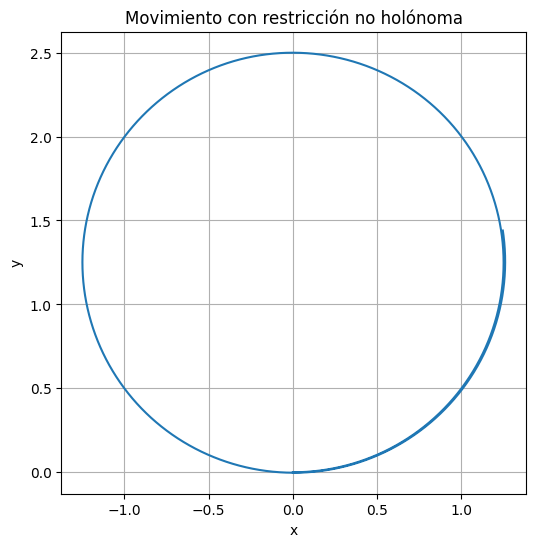

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros
m = 1.0
I = 1.0

# Sistema:
# estado = [x, y, theta, vx, vy, omega]
def sistema(t, estado):
    x, y, theta, vx, vy, omega = estado

    # velocidad hacia adelante
    v_forward = np.cos(theta)*vx + np.sin(theta)*vy

    # multiplicador de Lagrange
    lam = m * omega * v_forward

    # aceleraciones
    ax = -(lam/m)*np.sin(theta)
    ay =  (lam/m)*np.cos(theta)
    alpha = 0.0

    return [vx, vy, omega, ax, ay, alpha]


# Condiciones iniciales
x0 = 0.0
y0 = 0.0
theta0 = 0.0

v0 = 1.0
omega0 = 0.8

# Para satisfacer la restricción inicial:
vx0 = v0*np.cos(theta0)
vy0 = v0*np.sin(theta0)

estado0 = [x0, y0, theta0, vx0, vy0, omega0]

# Tiempo
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(sistema, t_span, estado0, t_eval=t_eval)

x = sol.y[0]
y = sol.y[1]
theta = sol.y[2]

# Gráfica de la trayectoria
plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Movimiento con restricción no holónoma")
plt.axis("equal")
plt.grid()
plt.show()

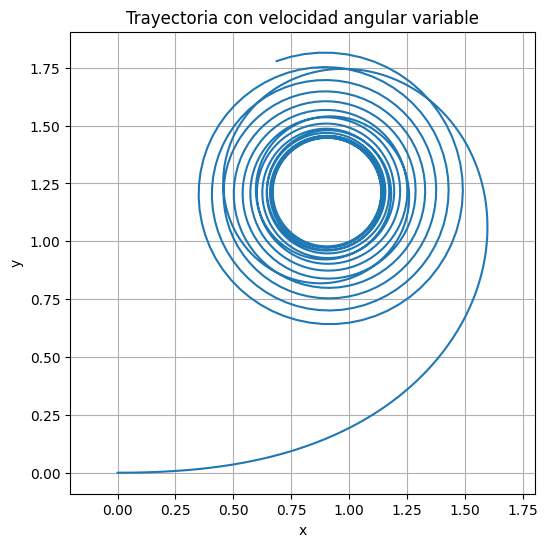

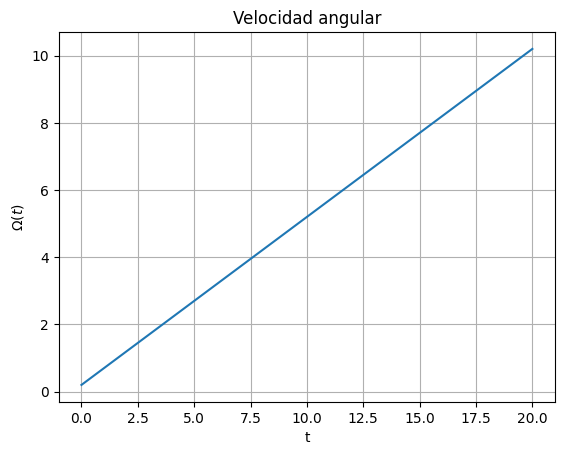

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 1.0
I = 1.0

def torque(t):
    #return 0.5*np.sin(2*t)
    # Para torque constante
    return 0.5

def sistema(t, estado):
    x, y, theta, vx, vy, omega = estado

    v = np.cos(theta)*vx + np.sin(theta)*vy

    ax = -omega*v*np.sin(theta)
    ay =  omega*v*np.cos(theta)

    alpha = torque(t)/I

    return [vx, vy, omega, ax, ay, alpha]

x0, y0 = 0.0, 0.0
theta0 = 0.0

v0 = 1.0
omega0 = 0.2

vx0 = v0*np.cos(theta0)
vy0 = v0*np.sin(theta0)

estado0 = [x0, y0, theta0, vx0, vy0, omega0]

t_eval = np.linspace(0, 20, 2000)

sol = solve_ivp(sistema, (0, 20), estado0, t_eval=t_eval)

x = sol.y[0]
y = sol.y[1]
theta = sol.y[2]
omega = sol.y[5]

plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.axis("equal")
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trayectoria con velocidad angular variable")
plt.show()

plt.figure()
plt.plot(t_eval, omega)
plt.grid()
plt.xlabel("t")
plt.ylabel(r"$\Omega(t)$")
plt.title("Velocidad angular")
plt.show()